In [ ]:
import sys
sys.path.append('..')

import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultrasound_tracker.preprocessing import load_video, preprocess
from ultrasound_tracker.klt_tracker import KLTTracker
from ultrasound_tracker.hough_detector import HoughDetector
from ultrasound_tracker.kalman_fusion import FascicleKalman

VIDEO_PATH = '../data/raw/UltraTimTrack_test.mp4'


Chargé : 2667 frames à 33.3 fps
Nombre de frames : 2667
FPS : 33.341
Résolution : (562, 706)


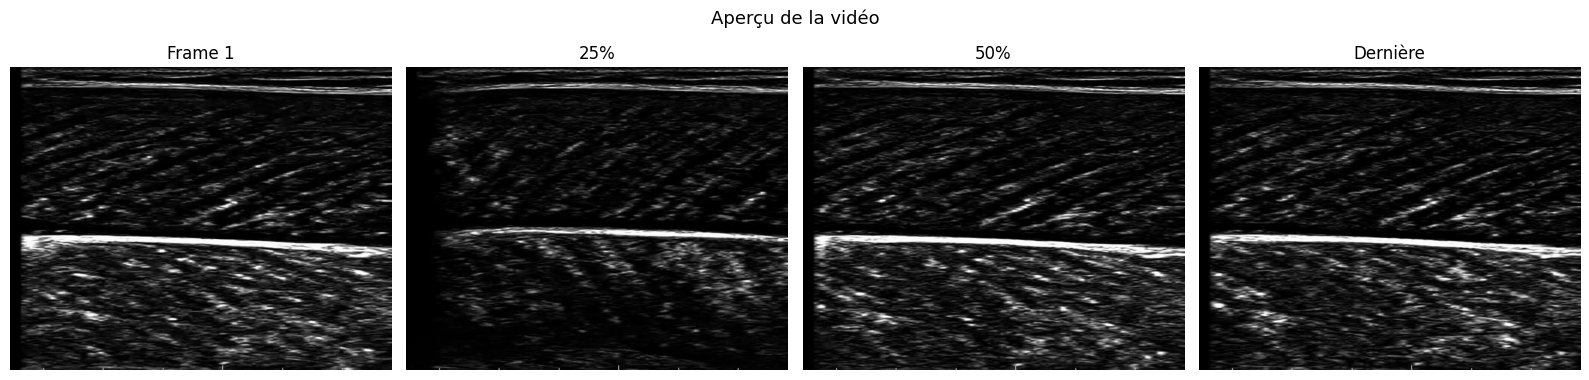

In [22]:
frames, fps = load_video(VIDEO_PATH)

print(f"Nombre de frames : {len(frames)}")
print(f"FPS : {fps}")
print(f"Résolution : {frames[0].shape}")

# Visualiser quelques frames clés
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
indices = [0, len(frames)//4, len(frames)//2, -1]
titres = ['Frame 1', '25%', '50%', 'Dernière']

for ax, idx, titre in zip(axes, indices, titres):
    ax.imshow(frames[idx], cmap='gray')
    ax.set_title(titre)
    ax.axis('off')

plt.suptitle('Aperçu de la vidéo', fontsize=13)
plt.tight_layout()
plt.show()

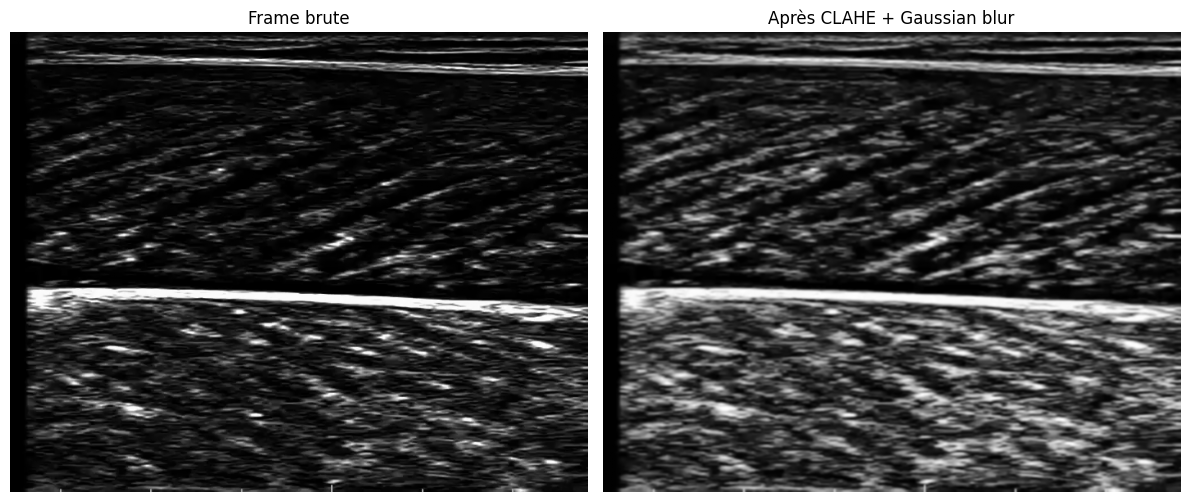

In [23]:
frame = frames[0]
processed = preprocess(frame, contrast=True, blur=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(frame, cmap='gray')
axes[0].set_title('Frame brute')
axes[1].imshow(processed, cmap='gray')
axes[1].set_title('Après CLAHE + Gaussian blur')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

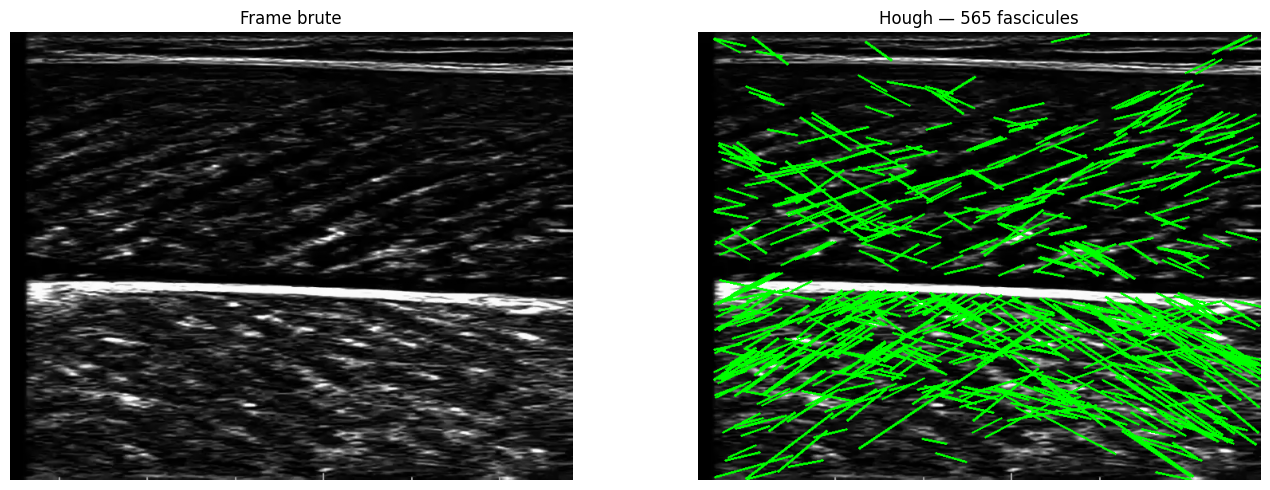

Angle médian    : 22.2°
Longueur médiane: 47.2 px


In [24]:
detector = HoughDetector(
    angle_min=10,
    angle_max=40,
    canny_low=30,
    canny_high=90,
    hough_threshold=40,
    min_line_length=30,
    max_line_gap=10
)

lines, angles, lengths = detector.detect(frames[0])

# Visualiser
vis = cv2.cvtColor(frames[0], cv2.COLOR_GRAY2BGR)
if lines is not None:
    for x1, y1, x2, y2 in lines:
        cv2.line(vis, (x1,y1), (x2,y2), (0,255,0), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(frames[0], cmap='gray')
axes[0].set_title('Frame brute')
axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Hough — {len(lines) if lines is not None else 0} fascicules')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

if angles is not None:
    print(f"Angle médian    : {np.median(angles):.1f}°")
    print(f"Longueur médiane: {np.median(lengths):.1f} px")

KLT initialisé : 49 points détectés


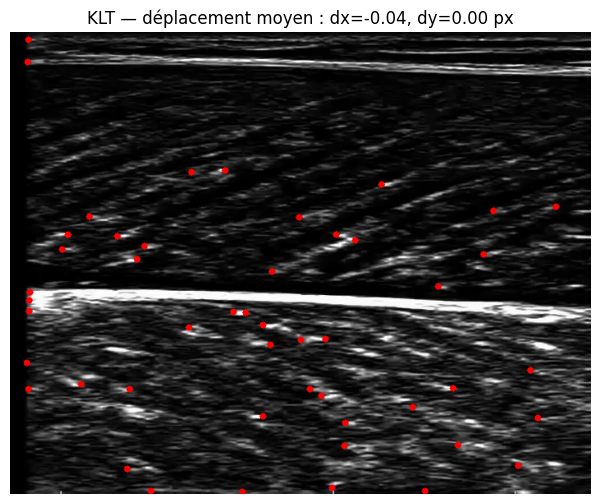

In [25]:
klt = KLTTracker(max_corners=50, quality_level=0.3)
klt.initialize(frames[0])

displacement, good_new, good_old = klt.update(frames[1])

# Visualiser
vis = cv2.cvtColor(frames[1], cv2.COLOR_GRAY2BGR)
if good_new is not None:
    for new, old in zip(good_new, good_old):
        x_new, y_new = new.ravel().astype(int)
        x_old, y_old = old.ravel().astype(int)
        cv2.arrowedLine(vis, (x_old,y_old), (x_new,y_new), (0,255,0), 2)
        cv2.circle(vis, (x_new,y_new), 4, (0,0,255), -1)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'KLT — déplacement moyen : dx={displacement[0]:.2f}, dy={displacement[1]:.2f} px')
plt.axis('off')
plt.show()

In [26]:
# Réinitialiser
klt = KLTTracker(max_corners=50, quality_level=0.3)
detector = HoughDetector(angle_min=10, angle_max=40)
kf = FascicleKalman(dt=1/fps)

results = {
    'frame': [],
    'hough_angle': [], 'hough_length': [],
    'klt_angle':   [], 'klt_length':   [],
    'kalman_angle':[], 'kalman_length':[]
}

klt.initialize(frames[0])
initialized = False

for i, frame in enumerate(frames):

    # --- Hough ---
    angle_h, length_h = detector.estimate(frame)

    # --- KLT ---
    displacement, _, _ = klt.update(frame)

    # --- Initialisation Kalman à la première mesure valide ---
    if not initialized and angle_h is not None:
        kf.initialize(angle_h, length_h)
        initialized = True

    if not initialized:
        continue

    # --- Kalman predict + update ---
    kf.predict(klt_displacement=displacement)
    if angle_h is not None:
        kf.update(angle_h, length_h)

    angle_k, length_k = kf.get_state()

    # --- Stocker ---
    results['frame'].append(i)
    results['hough_angle'].append(angle_h if angle_h else np.nan)
    results['hough_length'].append(length_h if length_h else np.nan)
    results['klt_angle'].append(displacement[1])
    results['klt_length'].append(displacement[0])
    results['kalman_angle'].append(angle_k)
    results['kalman_length'].append(length_k)

print(f"Traitement terminé — {len(results['frame'])} frames analysées")


KLT initialisé : 49 points détectés
Traitement terminé — 2667 frames analysées


In [31]:
import importlib
import ultrasound_tracker.utils as utils_module
importlib.reload(utils_module)
from ultrasound_tracker.utils import plot_results

plot_results(results, fps=fps,
             title="Python vs UltraTimTrack — Angle de pennation")


ImportError: cannot import name 'plot_results' from 'ultrasound_tracker.utils' (/Users/grosbedou/PycharmProjects/PythonProject/ultrasound_tracker/utils.py)